# Ice-slab tilt series (CPU: Shang–Sigworth @ 256³)

CPU end-to-end demo:

1. Pack **5** randomly oriented **6DRV** particles into a **256³** voxel box at **4 Å/px** (1024 Å cube)
2. Build a **Shang–Sigworth** solvated ESP
3. Simulate an untilted micrograph (1 µm underfocus)
4. Tilt the **ESP volume** about an **XY-plane axis** from **−60° … +60°** in **3°** steps (default tilt axis = Y; set `TILT_AXIS_ANGLE_DEG`). Out-of-bounds → bulk ice.

**Why rotate ESP (not rebuild atoms each tilt)?** The potential is a scalar field; a rigid specimen tilt is a resample of that volume. Rebuilding from atoms each tilt is much slower.

**Runtime:** Solvent geometry is the slow step on CPU; expect a long wait for ESP, then 41 tilts.

In [41]:
import mmdf
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from torch_calculate_electrostatic_potential import (
    GridConfig,
    default_sublattice_radius,
    solvated_potential_from_structure_3d,
)
from torch_scattering import multislice
from torch_structure_manipulation import (
    AtomicStructure,
    annotate_bonding_environments,
    apply_rotation,
    apply_translation,
    center_structure,
    create_rotation_matrix_from_euler,
)
from torch_transform_image import rotate_image_3d_about_tilt_axis

from torch_simulate_image import (
    CtfConfig,
    FluenceConfig,
    MicrographSimulationConfig,
    PoissonConfig,
    simulate_micrograph,
)


## Parameters


In [42]:
PIXEL_SIZE = 4.0  # Å
GRID_SHAPE = (256, 256, 256)  # Z, Y, X voxels → 1024 Å cube
N_PARTICLES = 5
VOLTAGE_KV = 300.0
ICE_POTENTIAL_V = 3.6
PROBE_RADIUS = 1.4
DEFOCUS_UM = 1.0
SEED = 0

# Packing: apoferritin ~120–130 Å across; use a generous exclusion sphere.
PARTICLE_RADIUS_A = 90.0  # Å; centers ≥ 2R apart and ≥ R from box faces

TILT_ANGLES_DEG = torch.arange(-60.0, 60.0 + 1e-6, 3.0)
# Tilt axis lies in the XY plane; angle from +X toward +Y (degrees).
# 0 → axis along X, 45 → x=y diagonal, 90 → along Y.
TILT_AXIS_ANGLE_DEG = 90.0
# Force CPU for this demo (GPUs may be busy).
DEVICE = torch.device("cpu")
print(
    f"device={DEVICE}, n_tilts={len(TILT_ANGLES_DEG)}, "
    f"tilt_axis_angle={TILT_AXIS_ANGLE_DEG}°, grid={GRID_SHAPE}"
)


device=cpu, n_tilts=41, tilt_axis_angle=90.0°, grid=(256, 256, 256)


## 1. Load and center template (6DRV)


In [43]:
atoms = mmdf.read("pdb:6drv")
template = annotate_bonding_environments(atoms, include_hydrogens=False)
template = center_structure(template, center_point=(0.0, 0.0, 0.0), zyx=False)

xyz = template[["x", "y", "z"]].to_numpy()
extent = xyz.max(axis=0) - xyz.min(axis=0)
print(f"template atoms={len(template)}, extent xyz Å={extent}")


template atoms=32888, extent xyz Å=[180.177 139.646  87.514]


## 2. Place 5 non-overlapping copies

Rejection sampling of centers inside the grid box, with random Euler orientations. Concatenate into one structure for a single ESP call.


In [44]:
rng = np.random.default_rng(SEED)

# Grid is centered at the origin (see GridConfig below).
half_span_a = (GRID_SHAPE[0] - 1) * PIXEL_SIZE / 2
lo = -half_span_a + PARTICLE_RADIUS_A
hi = half_span_a - PARTICLE_RADIUS_A
min_center_dist = 2.0 * PARTICLE_RADIUS_A


def sample_centers(n: int, max_tries: int = 100_000) -> np.ndarray:
    centers = []
    for _ in range(max_tries):
        if len(centers) >= n:
            break
        cand = rng.uniform(lo, hi, size=3)
        if all(np.linalg.norm(cand - c) >= min_center_dist for c in centers):
            centers.append(cand)
    if len(centers) < n:
        raise RuntimeError(f"only placed {len(centers)}/{n} non-overlapping centers")
    return np.asarray(centers)


centers = sample_centers(N_PARTICLES)
print("centers xyz Å:\n", np.round(centers, 1))

placed = []
for c in centers:
    angles = torch.tensor(rng.uniform(0.0, 360.0, size=3), dtype=torch.float32)
    R = create_rotation_matrix_from_euler(angles, order="ZYZ", degrees=True)
    mol = apply_rotation(template, R, zyx=False)
    mol = apply_translation(mol, tuple(c.tolist()), zyx=False)
    placed.append(mol)

slab_atoms = pd.concat(placed, ignore_index=True)
structure = AtomicStructure.from_dataframe(slab_atoms, device=DEVICE)
print(f"slab atoms={structure.num_atoms} on {structure.device}")


centers xyz Å:
 [[ 115.  -193.4 -385.6]
 [-406.1  263.1  346.7]
 [  89.6  192.8   36.6]
 [ 365.5  265.3 -417.7]
 [ 300.2 -391.8  192.9]]
slab atoms=164440 on cpu


## 3. Solvated ESP (Shang–Sigworth)

Atomic ESP plus continuum hydration (`solvent_model="shang_sigworth"`). One 256³ volume in volts — the expensive step on CPU.

In [45]:
grid = GridConfig.from_grid_shape_and_voxel_size(
    grid_shape=GRID_SHAPE,
    voxel_size=(PIXEL_SIZE, PIXEL_SIZE, PIXEL_SIZE),
    center_zyx=(0.0, 0.0, 0.0),
    sublattice_radius=default_sublattice_radius(PIXEL_SIZE),
    equal_length=False,
    device=DEVICE,
)
print("grid shape:", tuple(int(n) for n in grid.grid_shape.tolist()))
print("left_bottom Å:", grid.left_bottom_point.tolist())
print("right_upper Å:", grid.right_upper_point.tolist())

print("building Shang–Sigworth solvated ESP …")
volume = solvated_potential_from_structure_3d(
    structure,
    grid,
    model_water_potential=True,
    solvent_model="shang_sigworth",
    ice_potential_V=ICE_POTENTIAL_V,
    probe_radius=PROBE_RADIUS,
    scattering_factors="peng_bonded",
    bonded_fallback="elemental",
)
volume.shape, float(volume.mean()), float(volume[0, 0, 0])


grid shape: (256, 256, 256)
left_bottom Å: [-510.0, -510.0, -510.0]
right_upper Å: [510.0, 510.0, 510.0]
building Shang–Sigworth solvated ESP …


/home/jdickerson/git/teamtomo/teamtomo_main/teamtomo/packages/primitives/torch-calculate-electrostatic-potential/src/torch_calculate_electrostatic_potential/structure.py:132: UserWarning: unsupported bonded scattering parameters (atom 4: protein key 'C(CC)'; atom 5: protein key 'C(CS)'; atom 7: protein key 'C(S)'; and 48697 more); using elemental fallback
  return resolve_scattering_parameters(


(torch.Size([256, 256, 256]), 3.6042349338531494, 3.5999999046325684)

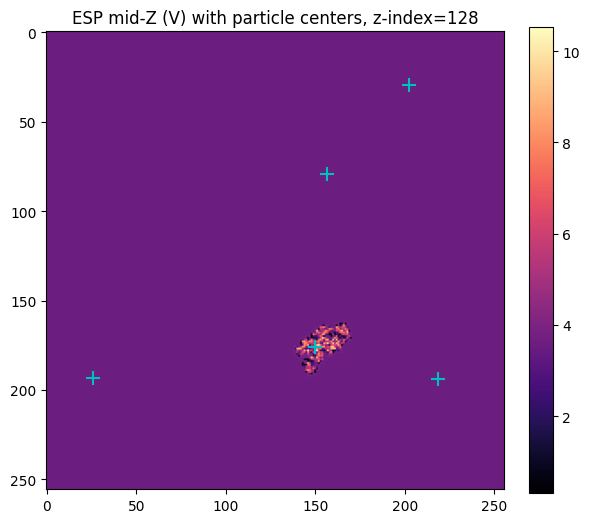

In [48]:
mid_z = volume.shape[0] // 2
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(volume[mid_z].detach().cpu().numpy(), cmap="magma")
lb = grid.left_bottom_point.detach().cpu().numpy()
vs = grid.voxel_size.detach().cpu().numpy()
for c in centers:
    col = (c[0] - lb[2]) / vs[2]
    row = (c[1] - lb[1]) / vs[1]
    ax.plot(col, row, "c+", markersize=10, markeredgewidth=1.5)
ax.set_title(f"ESP mid-Z (V) with particle centers, z-index={mid_z}")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## 4. Untilted micrograph

CTF at **1.0 µm** underfocus. Poisson sampling on (deterministic with `SEED`).

untilted multislice …


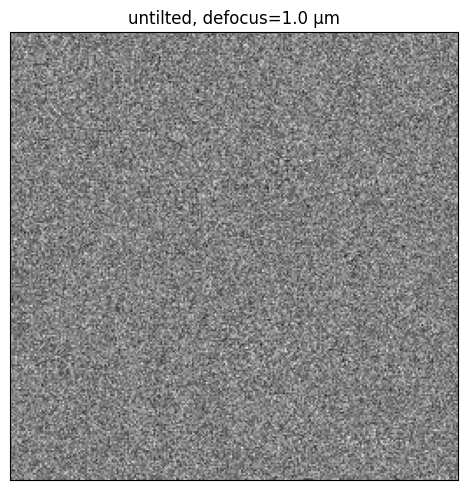

torch.Size([256, 256])

In [51]:
config = MicrographSimulationConfig(
    pixel_size=PIXEL_SIZE,
    ctf=CtfConfig(defocus_um=DEFOCUS_UM, voltage_kv=VOLTAGE_KV),
    fluence=FluenceConfig(dose_e_per_A2=3.0),  # e⁻/Å² per tilt
    poisson=PoissonConfig(apply=True, deterministic=True, seed=SEED),
)

print("untilted multislice …")
exit_wave_0 = multislice(volume, pixel_size=PIXEL_SIZE, voltage=VOLTAGE_KV)
micrograph_0 = simulate_micrograph(exit_wave_0, config)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(micrograph_0.detach().cpu().numpy(), cmap="gray")
ax.set_title(f"untilted, defocus={DEFOCUS_UM} µm")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()
micrograph_0.shape


## 5. Tilt series (−60° … +60°, step 3°)

`rotate_image_3d_about_tilt_axis` (from `torch-transform-image`) rotates about an axis **in the XY plane**. Set `TILT_AXIS_ANGLE_DEG` in Parameters:

| `tilt_axis_angle` | Tilt axis |
|---|---|
| `0` | along **X** |
| `45` | along **x = y** |
| `90` (default) | along **Y** |

Ice pad in the notebook: subtract bulk ice before rotating and add it back so out-of-bounds voxels (zeroed by sampling) become ice MIP.

In [52]:
def rotate_volume_with_ice_pad(
    pot: torch.Tensor,
    tilt_deg: float,
    tilt_axis_angle: float = 90.0,
    ice_potential_v: float = 0.0,
) -> torch.Tensor:
    """Rotate ESP; fill out-of-bounds with bulk ice after sampling zeros."""
    contrast = pot - ice_potential_v
    rotated = rotate_image_3d_about_tilt_axis(
        contrast,
        tilt_deg=tilt_deg,
        tilt_axis_angle=tilt_axis_angle,
    )
    return rotated + ice_potential_v


tilt_angles = TILT_ANGLES_DEG.to(dtype=torch.float32)
micrographs = []

for i, tilt in enumerate(tilt_angles.tolist()):
    print(
        f"tilt {i + 1}/{len(tilt_angles)}: "
        f"{tilt:+.0f}° (axis at {TILT_AXIS_ANGLE_DEG:.1f}° from X) …"
    )
    tilted_vol = rotate_volume_with_ice_pad(
        volume,
        tilt,
        tilt_axis_angle=TILT_AXIS_ANGLE_DEG,
        ice_potential_v=ICE_POTENTIAL_V,
    )
    ew = multislice(tilted_vol, pixel_size=PIXEL_SIZE, voltage=VOLTAGE_KV)
    micrographs.append(simulate_micrograph(ew, config).detach().cpu())

micrograph_stack = torch.stack(micrographs, dim=0)  # (n_tilts, H, W)
print("stack:", tuple(micrograph_stack.shape))


tilt 1/41: -60° (axis at 90.0° from X) …
tilt 2/41: -57° (axis at 90.0° from X) …
tilt 3/41: -54° (axis at 90.0° from X) …
tilt 4/41: -51° (axis at 90.0° from X) …
tilt 5/41: -48° (axis at 90.0° from X) …
tilt 6/41: -45° (axis at 90.0° from X) …
tilt 7/41: -42° (axis at 90.0° from X) …
tilt 8/41: -39° (axis at 90.0° from X) …
tilt 9/41: -36° (axis at 90.0° from X) …
tilt 10/41: -33° (axis at 90.0° from X) …
tilt 11/41: -30° (axis at 90.0° from X) …
tilt 12/41: -27° (axis at 90.0° from X) …
tilt 13/41: -24° (axis at 90.0° from X) …
tilt 14/41: -21° (axis at 90.0° from X) …
tilt 15/41: -18° (axis at 90.0° from X) …
tilt 16/41: -15° (axis at 90.0° from X) …
tilt 17/41: -12° (axis at 90.0° from X) …
tilt 18/41: -9° (axis at 90.0° from X) …
tilt 19/41: -6° (axis at 90.0° from X) …
tilt 20/41: -3° (axis at 90.0° from X) …
tilt 21/41: +0° (axis at 90.0° from X) …
tilt 22/41: +3° (axis at 90.0° from X) …
tilt 23/41: +6° (axis at 90.0° from X) …
tilt 24/41: +9° (axis at 90.0° from X) …
tilt 25/

## 6. Montage of selected tilts


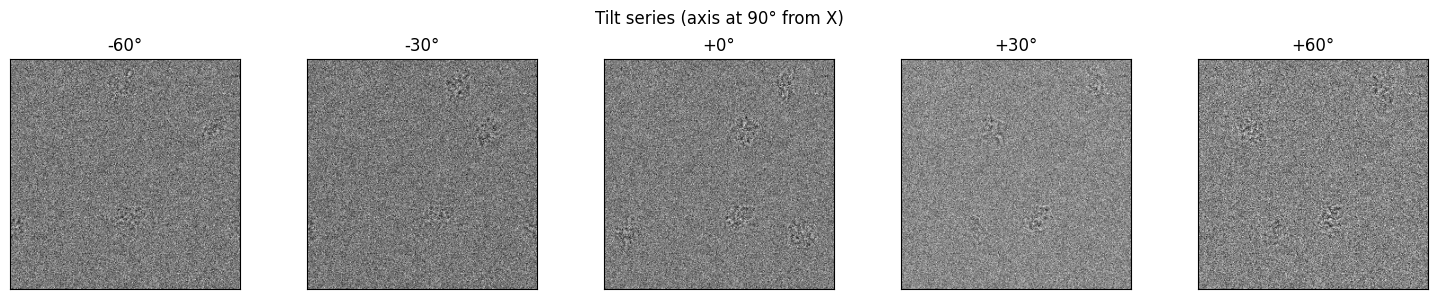

In [50]:
show_angles = (-60.0, -30.0, 0.0, 30.0, 60.0)
fig, axes = plt.subplots(1, len(show_angles), figsize=(15, 3))
for ax, ang in zip(axes, show_angles):
    idx = int(torch.argmin(torch.abs(tilt_angles - ang)).item())
    ax.imshow(micrograph_stack[idx].numpy(), cmap="gray")
    ax.set_title(f"{float(tilt_angles[idx]):+.0f}°")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"Tilt series (axis at {TILT_AXIS_ANGLE_DEG:.0f}° from X)")
plt.tight_layout()
plt.show()
